In [1]:
import numpy as np
import pandas as pd
import os
# PyTorch & vision
import torch
import torchvision

# Computer vision / images
import cv2
from PIL import Image
from pathlib import Path
# Scientific / plotting
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

# ML / preprocessing / metrics
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

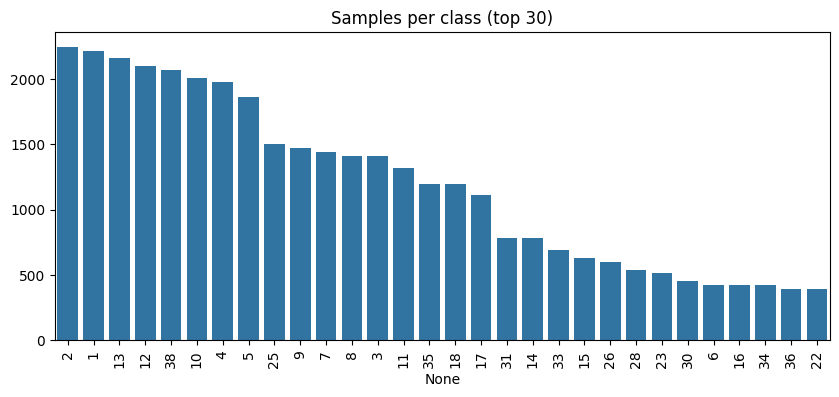

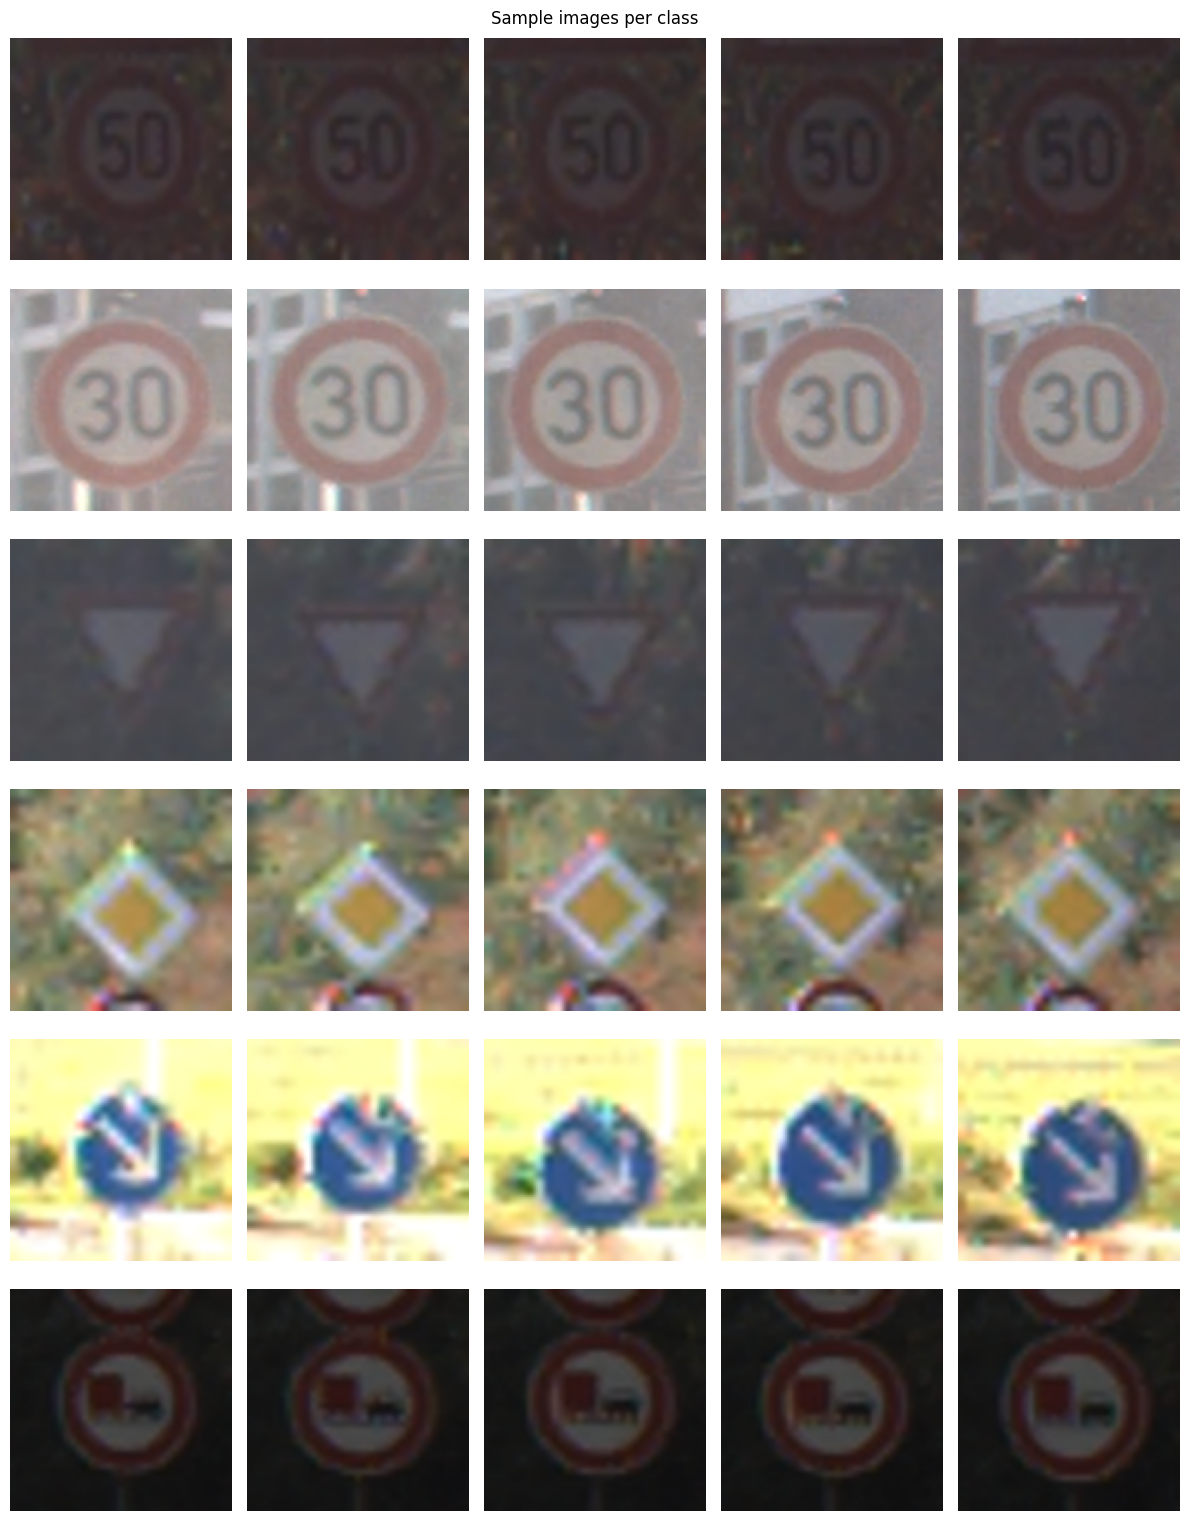

In [2]:


base = Path(r"d:\school\comp4471\project\archive")
train_folder = base / "Train"


# class counts and barplot
counts = {d.name: sum(1 for _ in d.glob("*.*")) for d in sorted(train_folder.iterdir()) if d.is_dir()}
s = pd.Series(counts).sort_values(ascending=False)
plt.figure(figsize=(10,4)); sns.barplot(x=s.index[:30], y=s.values[:30]); plt.xticks(rotation=90); plt.title("Samples per class (top 30)"); plt.show()

# show samples from first 6 classes
def show_samples():
    classes = list(s.index[:6])
    fig, axs = plt.subplots(len(classes), 5, figsize=(12, 2.6*len(classes)))
    for i,c in enumerate(classes):
        imgs = list((train_folder/c).glob("*.*"))[:5]
        for j in range(5):
            ax = axs[i][j] if len(classes)>1 else axs[j]
            ax.axis("off")
            if j < len(imgs):
                ax.imshow(Image.open(imgs[j]).convert("RGB").resize((128,128)))
            if j==0:
                ax.set_ylabel(c, rotation=0, labelpad=40, va="center")
    plt.suptitle("Sample images per class"); plt.tight_layout(); plt.show()
show_samples()


Resize all the images to 32 and 32 and applying z-score to each of photo as the light of each photo might be difference

In [4]:
#make the dataset to npo array with resized images to 64x64
IMG_SIZE = (64, 64)
paths = sorted((Path(r"d:\school\comp4471\project\archive") / "Train").glob("*/*.*"))
X = np.stack([np.asarray(Image.open(p).convert("RGB").resize(IMG_SIZE), dtype=np.uint8) for p in paths])
y = np.array([p.parent.name for p in paths])

np.savez("train_64_raw.npz", X=X, y=y, classes=np.unique(y))
print("saved train_64_raw.npz", "X.shape:", X.shape, "dtype:", X.dtype, "y.shape:", y.shape)

saved train_64_raw.npz X.shape: (39209, 64, 64, 3) dtype: uint8 y.shape: (39209,)


In [11]:
#min-max normalization per image
IMG_SIZE = (64, 64)
X, y = [], []
classes = sorted([d.name for d in train_folder.iterdir() if d.is_dir()])

for c in classes:
    for p in (train_folder / c).glob("*.*"):
        im = Image.open(p).convert("RGB").resize(IMG_SIZE)
        arr = np.asarray(im, dtype=np.float32)            # 0..255
        mn, mx = arr.min(), arr.max()
        if mx > mn:
            arr = (arr - mn) / (mx - mn)                  # per-image min-max -> 0..1
        else:
            arr = arr - mn                                # constant image -> zeros
        X.append(arr)
        y.append(c)

X = np.stack(X).astype(np.float32)                       # (N,32,32,3)
y = np.array(y)
np.savez("train_64_minmax.npz", X=X, y=y, classes=np.array(classes))
print("Saved train_64_minmax.npz", X.shape, y.shape)

Saved train_64_minmax.npz (39209, 64, 64, 3) (39209,)


In [12]:
# Vectorized global z-score normalization 
import numpy as np

data = np.load("train_64_raw.npz", allow_pickle=True)
X = data["X"].astype(np.float32)     # (N,H,W,3)
y = data["y"]
classes = data.get("classes")

# per-channel mean/std across all images and pixels
mean_c = X.mean(axis=(0,1,2))        # shape (3,)
std_c  = X.std(axis=(0,1,2))
std_c  = np.maximum(std_c, 1e-6)     # avoid div by zero

# apply broadcasting to normalize all images at once
X_norm = (X - mean_c.reshape(1,1,1,3)) / std_c.reshape(1,1,1,3)

# save normalized dataset and stats
np.savez("train_64_globalz.npz", X=X_norm.astype(np.float32), y=y, classes=classes, mean=mean_c, std=std_c)
print("Saved:", "train_64_globalz.npz", "X.shape:", X_norm.shape, "mean:", mean_c, "std:", std_c)

Saved: train_64_globalz.npz X.shape: (39209, 64, 64, 3) mean: [26.743248 26.743248 26.743248] std: [82.742195 78.84423  82.742195]


In [13]:
# Convert RGB to HLS and normalize to [0,1]
data = np.load("train_64_raw.npz", allow_pickle=True)
X_raw = data["X"]
y = data["y"]
classes = data.get("classes", np.unique(y))

X_hls = np.empty(X_raw.shape, dtype=np.float32)

for i, img in enumerate(X_raw):
    hls = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)
    hls = hls.astype(np.float32)
    hls[...,0] /= 180.0  # Normalize H to 0-1
    hls[...,1] /= 255.0  # Normalize L to 0-1
    hls[...,2] /= 255.0  # Normalize S to 0-1
    X_hls[i] = hls

np.savez("train_64_hls.npz", X=X_hls, y=y, classes=classes)
print("saved train_64_hls.npz", X_hls.shape)

saved train_64_hls.npz (39209, 64, 64, 3)


In [7]:
#Apply CLAHE to the Lightness channel for lighting normalization
data = np.load("train_64_raw.npz", allow_pickle=True)
X_raw = data["X"]
y = data["y"]
classes = data.get("classes", np.unique(y))

# Create a CLAHE object (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

X_clahe = np.empty_like(X_raw)

for i, img_rgb in enumerate(X_raw):
    # Convert to HLS color space
    img_hls = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HLS)
    
    # Apply CLAHE to the L (lightness) channel (index 1)
    img_hls[:, :, 1] = clahe.apply(img_hls[:, :, 1])
    
    # Convert back to RGB
    img_rgb_eq = cv2.cvtColor(img_hls, cv2.COLOR_HLS2RGB)
    
    X_clahe[i] = img_rgb_eq

np.savez("train_64_clahe.npz", X=X_clahe, y=y, classes=classes)
print("Saved train_64_clahe.npz", "X.shape:", X_clahe.shape)

Saved train_64_clahe.npz X.shape: (39209, 64, 64, 3)


In [8]:
def visualize_npz(filepath, top_k=6, per_class=5):
    """
    Loads and visualizes image data from a specified .npz file.
    
    Args:
        filepath (str): The path to the .npz file.
        top_k (int): The number of top classes to display.
        per_class (int): The number of samples to show for each class.
    """
    try:
        data = np.load(filepath, allow_pickle=True)
        X, y = data['X'], data['y']
    except FileNotFoundError:
        print(f"Error: File not found at '{filepath}'")
        return
    except KeyError:
        print(f"Error: .npz file '{filepath}' must contain 'X' and 'y' arrays.")
        return

    print(f"Loaded '{filepath}':")
    print(f"  X shape: {X.shape}, dtype: {X.dtype}")
    print(f"  y shape: {y.shape}, dtype: {y.dtype}")

    # Determine how to display images based on dtype
    is_float = np.issubdtype(X.dtype, np.floating)
    
    # Get top classes
    counts = pd.Series(y).value_counts()
    top_classes = counts.index[:top_k].tolist()

    fig, axs = plt.subplots(len(top_classes), per_class, figsize=(per_class * 2.5, len(top_classes) * 2.6))
    if len(top_classes) == 1:
        axs = [axs]

    for i, cls in enumerate(top_classes):
        idxs = np.where(y == cls)[0][:per_class]
        for j in range(per_class):
            ax = axs[i][j]
            ax.axis("off")
            if j < len(idxs):
                img = X[idxs[j]]
                # Clip float images to the valid [0,1] range for display
                if is_float:
                    img = np.clip(img, 0, 1)
                ax.imshow(img)
            if j == 0:
                ax.set_ylabel(str(cls), rotation=0, labelpad=40, va="center")
                
    plt.suptitle(f"Samples from {filepath}")
    plt.tight_layout()
    plt.show()

Loaded 'train_64_minmax.npz':
  X shape: (39209, 64, 64, 3), dtype: float32
  y shape: (39209,), dtype: <U2


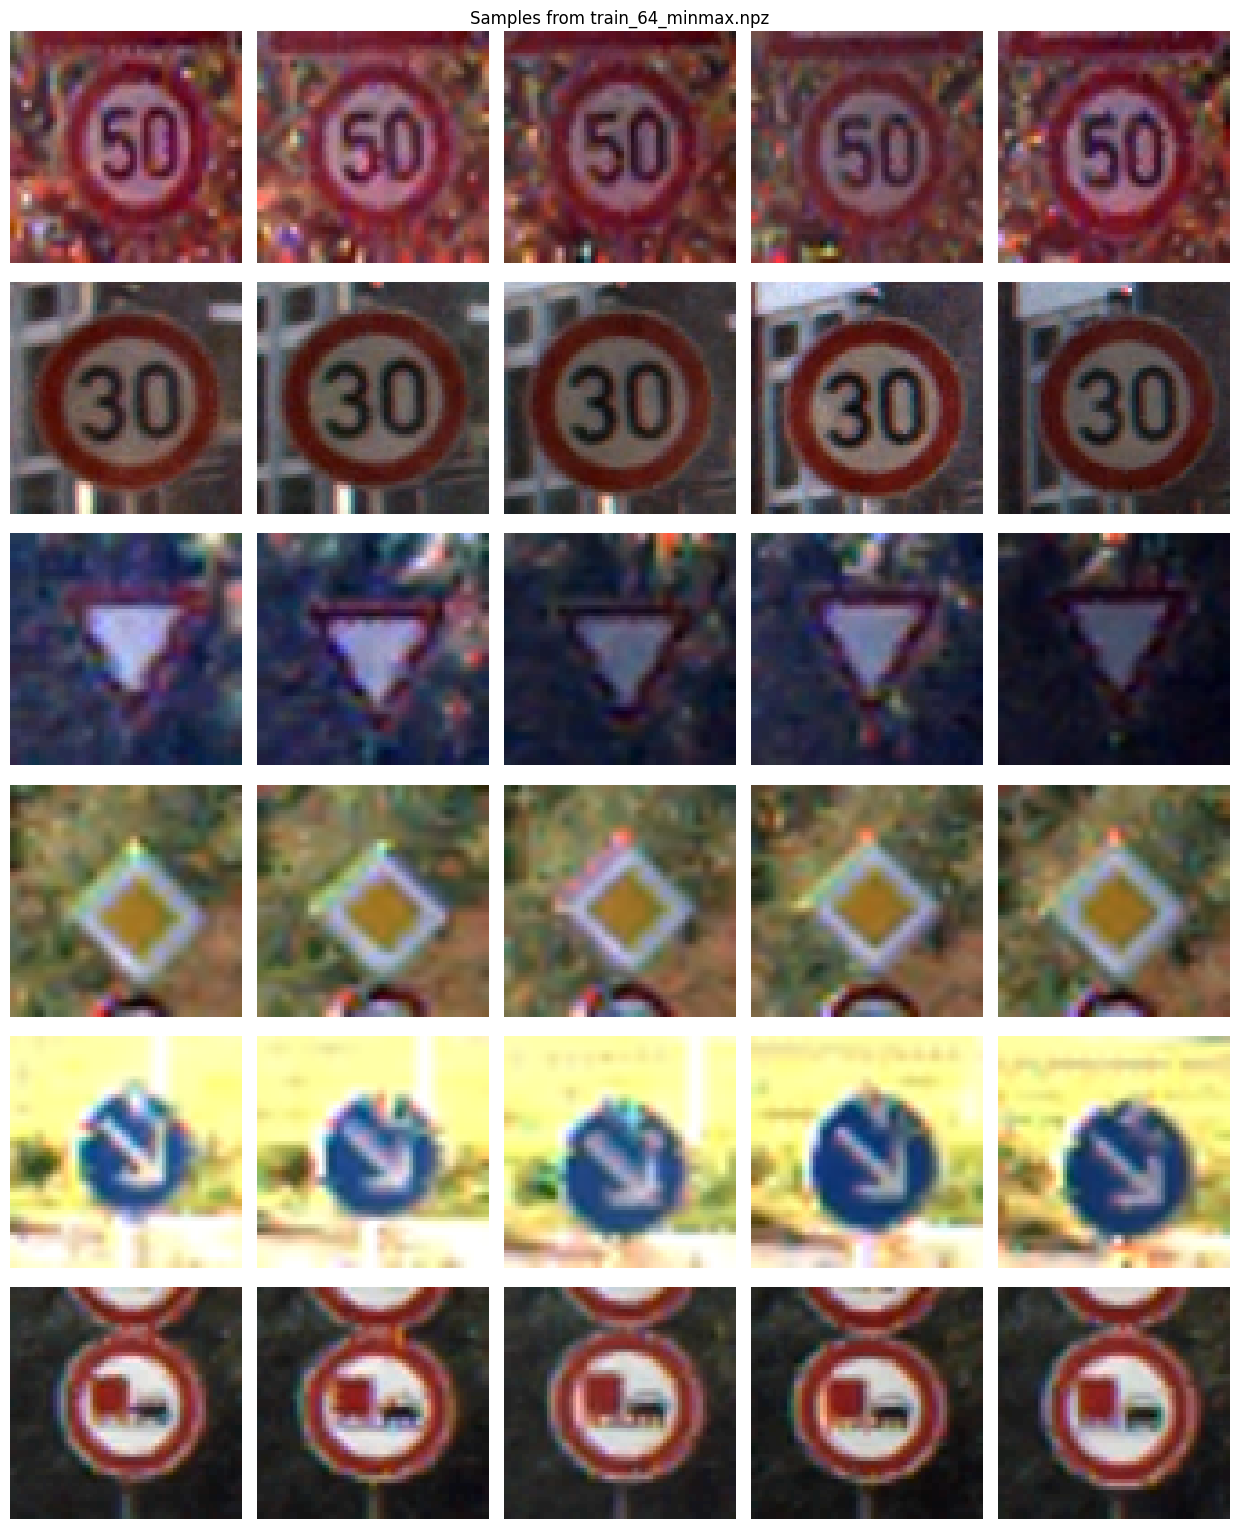

Loaded 'train_64_globalz.npz':
  X shape: (39209, 64, 64, 3), dtype: float32
  y shape: (39209,), dtype: <U2


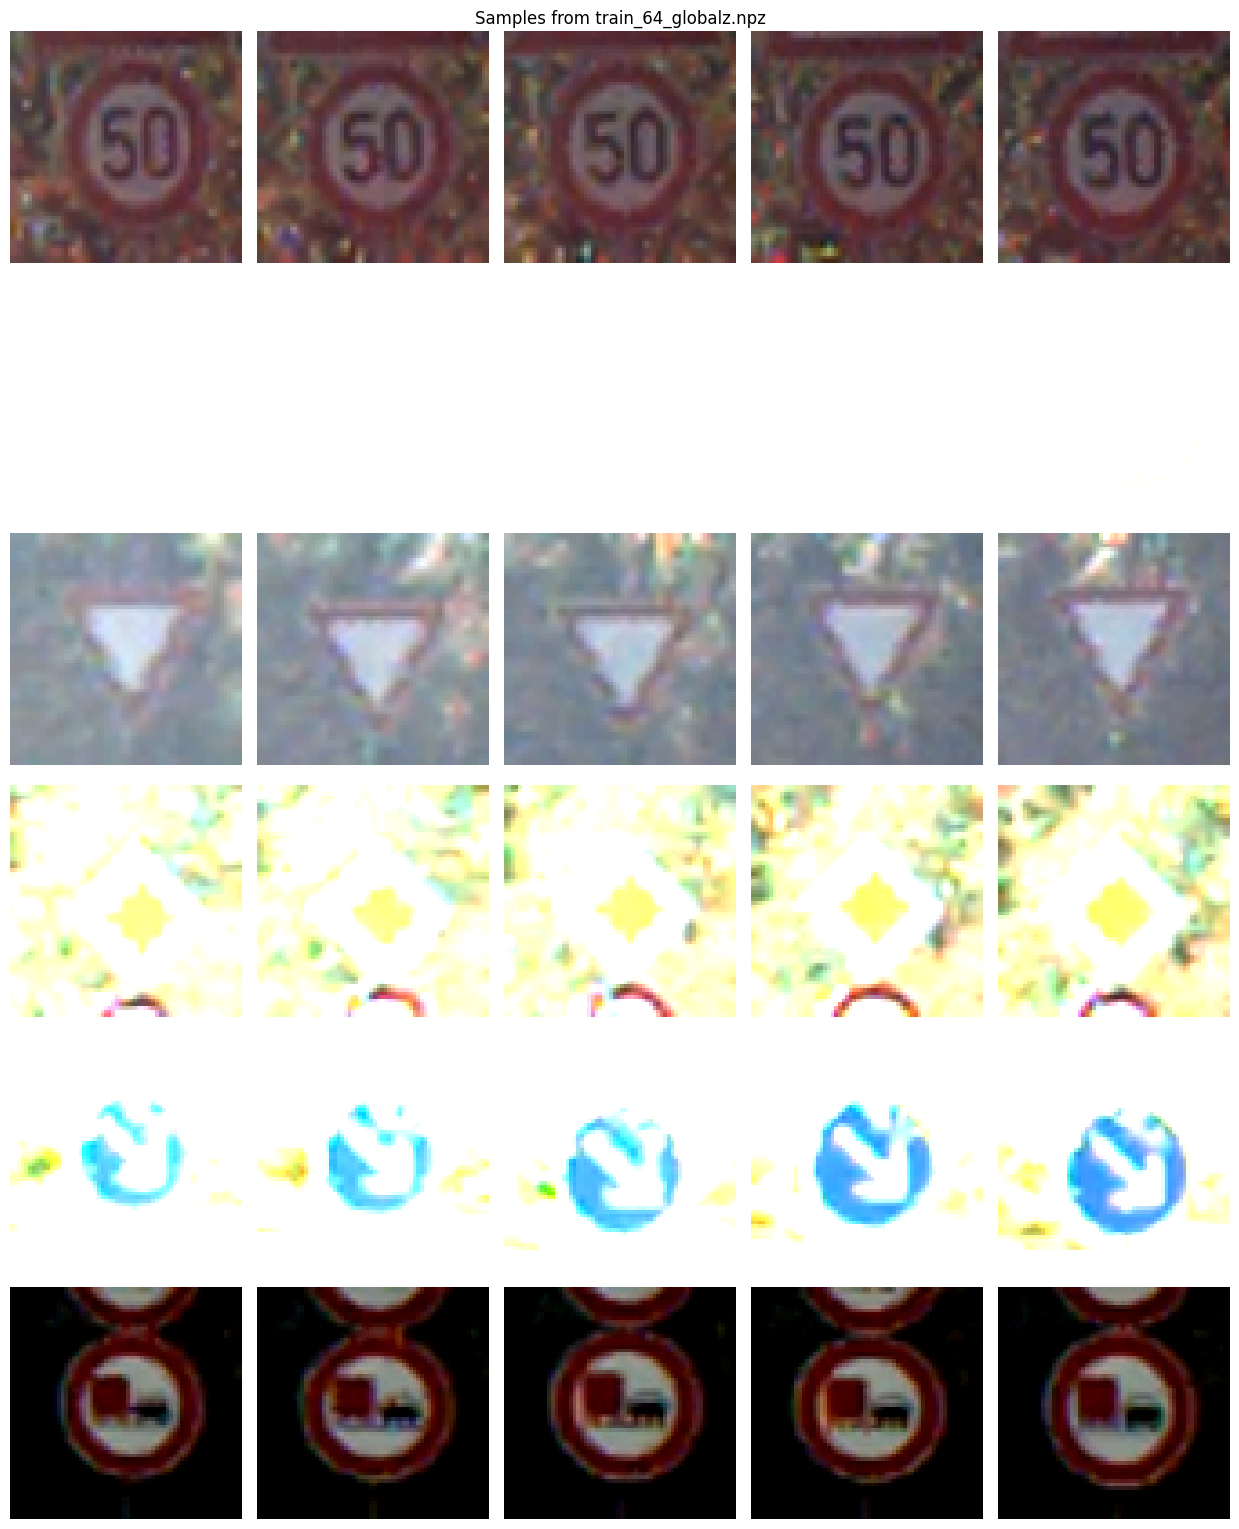

Loaded 'train_64_hls.npz':
  X shape: (39209, 64, 64, 3), dtype: float32
  y shape: (39209,), dtype: <U2


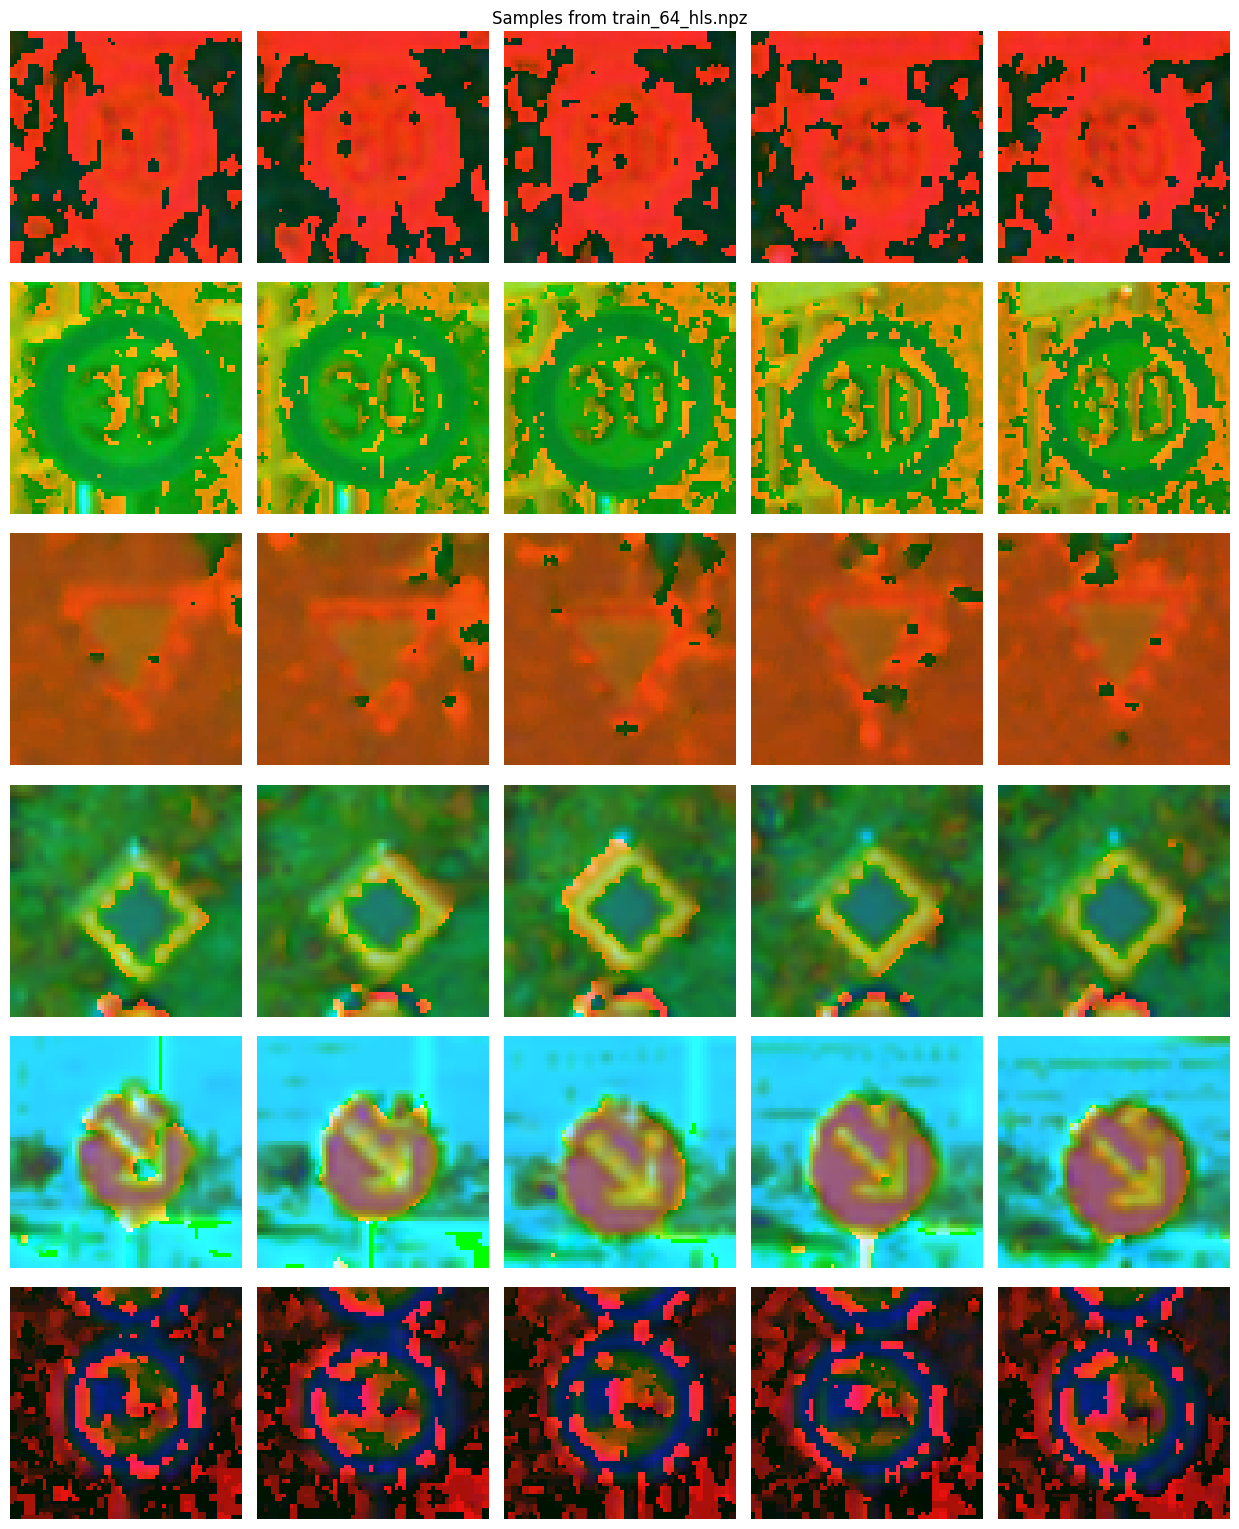

Loaded 'train_64_clahe.npz':
  X shape: (39209, 64, 64, 3), dtype: uint8
  y shape: (39209,), dtype: <U2


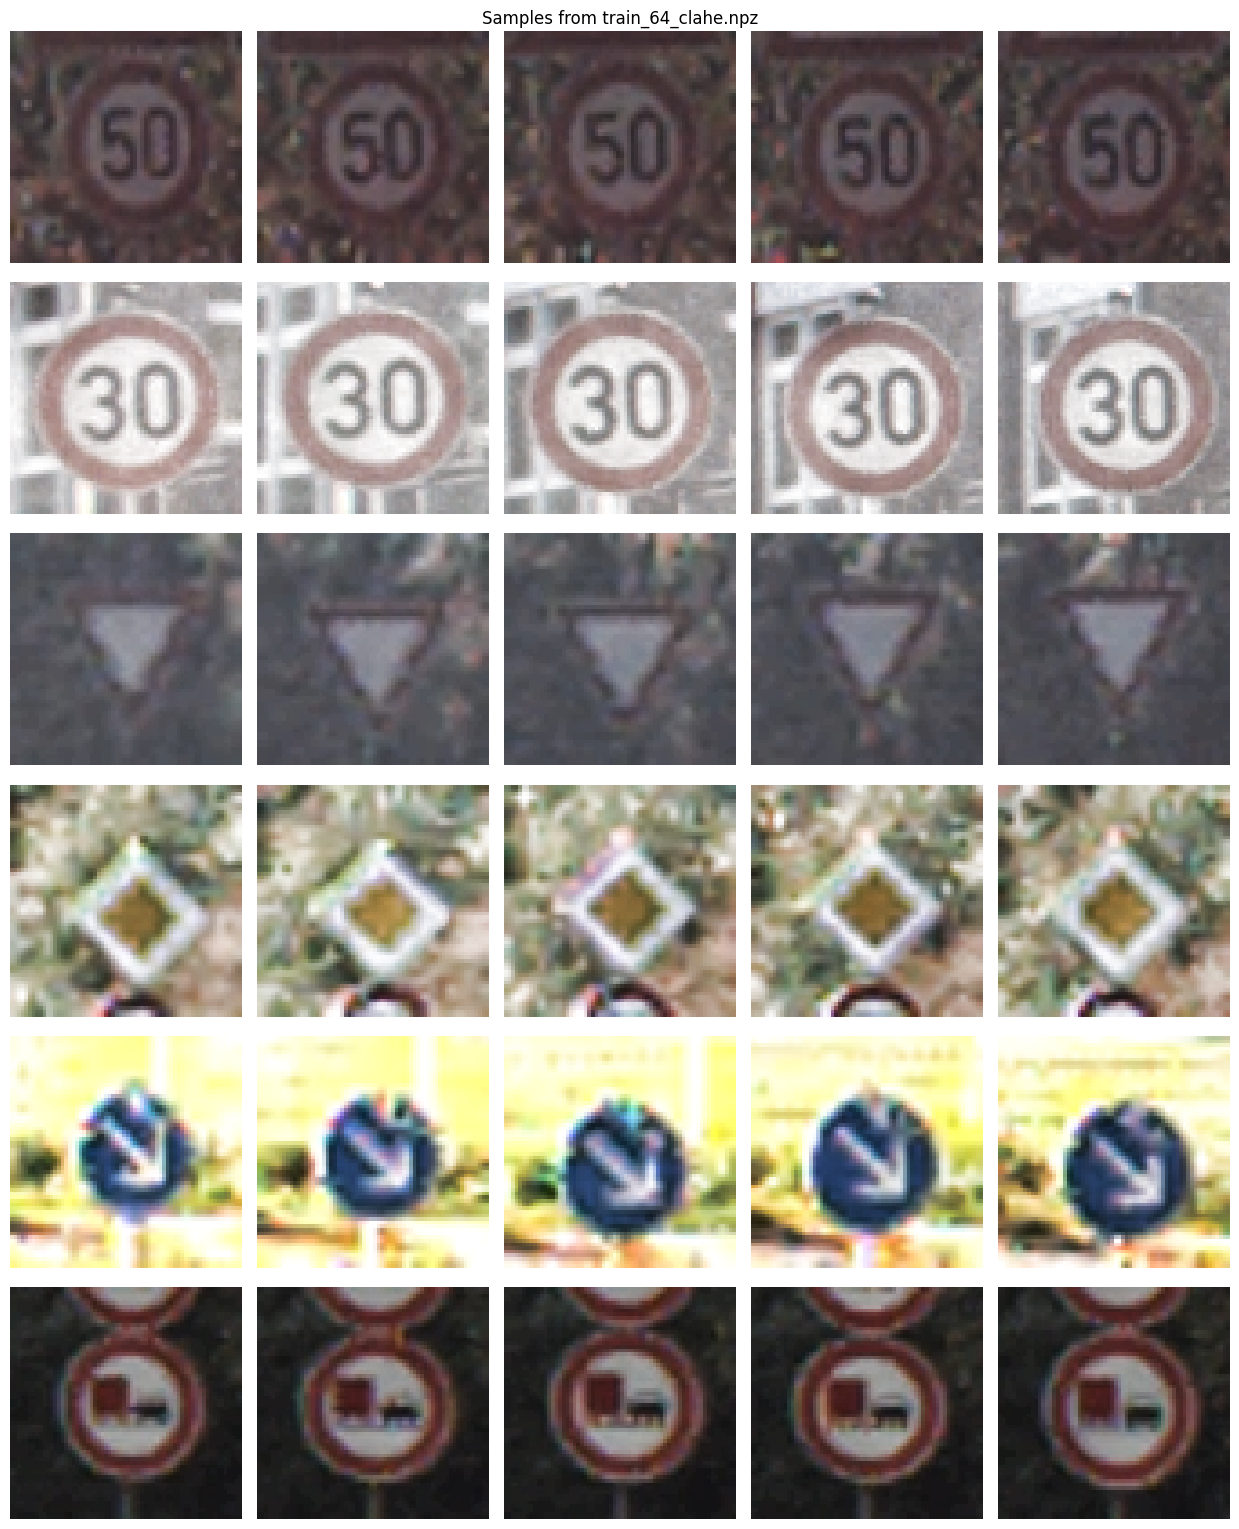

In [15]:
visualize_npz("train_64_minmax.npz")
visualize_npz("train_64_globalz.npz")
visualize_npz("train_64_hls.npz")
visualize_npz("train_64_clahe.npz")

SO I think the best preprocesssing method is clahe , and 32*32 is too small so enlarged to 64*64

Applying the best preprocessing method and image size to test set

In [16]:
IMG_SIZE = (64, 64)
test_base_path = Path(r"d:\school\comp4471\project\archive")
test_csv_path = test_base_path / "Test.csv" # Path to the main annotation CSV

X_test, y_test = [], []

try:
    # Read the CSV file to get filenames and class IDs
    # The GTSRB test CSV uses a semicolon (;) separator
    test_df = pd.read_csv(test_csv_path)
    
    # Filter for rows that are part of the test set, identified by the 'Test/' prefix in the Path
    test_df = test_df[test_df['Path'].str.startswith('Test/')]

    for index, row in test_df.iterrows():
        # Construct the full path to the image
        img_path = test_base_path / row['Path']
        
        # Open, resize, and convert the image
        im = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        arr = np.asarray(im, dtype=np.uint8)
        
        # Get the corresponding class label from the 'ClassId' column
        label = str(row['ClassId'])
        
        X_test.append(arr)
        y_test.append(label)

    X_test = np.stack(X_test)
    y_test = np.array(y_test)
    
    # Get the unique class names from the training set to ensure consistency
    train_data = np.load("train_64_raw.npz")
    train_classes = train_data['classes']

    np.savez("test_64_raw.npz", X=X_test, y=y_test, classes=train_classes)
    print("Saved test_64_raw.npz", "X.shape:", X_test.shape, "dtype:", X_test.dtype, "y.shape:", y_test.shape)

except FileNotFoundError:
    print(f"Error: Could not find the test CSV file at '{test_csv_path}'")
except Exception as e:
    print(f"An error occurred: {e}")

Saved test_64_raw.npz X.shape: (12630, 64, 64, 3) dtype: uint8 y.shape: (12630,)


In [17]:
#Apply CLAHE to the Lightness channel for lighting normalization to test set
data = np.load("test_64_raw.npz", allow_pickle=True)
X_raw = data["X"]
y = data["y"]
classes = data.get("classes", np.unique(y))

# Create a CLAHE object (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

X_clahe = np.empty_like(X_raw)

for i, img_rgb in enumerate(X_raw):
    # Convert to HLS color space
    img_hls = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HLS)
    
    # Apply CLAHE to the L (lightness) channel (index 1)
    img_hls[:, :, 1] = clahe.apply(img_hls[:, :, 1])
    
    # Convert back to RGB
    img_rgb_eq = cv2.cvtColor(img_hls, cv2.COLOR_HLS2RGB)
    
    X_clahe[i] = img_rgb_eq

np.savez("test_64_clahe.npz", X=X_clahe, y=y, classes=classes)
print("Saved test_64_clahe.npz", "X.shape:", X_clahe.shape)

Saved test_64_clahe.npz X.shape: (12630, 64, 64, 3)


KNN with numpy

In [21]:
# Cell: Fully Vectorized k-NN Classifier (No Loops)

import numpy as np
from scipy.stats import mode
from sklearn.metrics import classification_report

# 1. Load the datasets
try:
    train_data = np.load("train_64_clahe.npz")
    X_train = train_data['X']
    y_train = train_data['y']

    test_data = np.load("test_64_clahe.npz")
    X_test = test_data['X']
    y_test = test_data['y']
except FileNotFoundError as e:
    print(f"Error loading data: {e}. Please ensure your .npz files exist.")
    X_train = None
    
if X_train is not None:
    y_train = y_train.astype(np.int32)
    y_test = y_test.astype(np.int32)
    # 2. Reshape data into 2D arrays for matrix multiplication
    # Flatten images from (N, 64, 64, 3) to (N, 12288)
    num_train, num_test = X_train.shape[0], X_test.shape[0]
    X_train_flat = X_train.reshape(num_train, -1).astype(np.float32)
    X_test_flat = X_test.reshape(num_test, -1).astype(np.float32)

    print(f"Training data shape (flat): {X_train_flat.shape}")
    print(f"Test data shape (flat):     {X_test_flat.shape}")

    # 3. Fully Vectorized Distance Calculation
    # Calculate squared L2 distance matrix using the identity:
    # (a - b)^2 = a^2 - 2ab + b^2
    
    # Calculate sum of squares for each test image -> shape (num_test,)
    test_sq = np.sum(X_test_flat**2, axis=1)
    # Calculate sum of squares for each training image -> shape (num_train,)
    train_sq = np.sum(X_train_flat**2, axis=1)
    
    # Calculate the dot product term (2ab) for all pairs -> shape (num_test, num_train)
    dot_product = X_test_flat @ X_train_flat.T
    
    # Combine the terms using broadcasting to get the full (num_test, num_train) distance matrix
    dists_sq = test_sq[:, np.newaxis] - 2 * dot_product + train_sq

    # 4. Find k-nearest neighbors and predict
    k = 5
    # Get indices of the k smallest distances for each test sample
    # This gives a (num_test, k) array of indices
    k_nearest_indices = np.argsort(dists_sq, axis=1)[:, :k]
    
    # Get the labels of the k-nearest neighbors -> shape (num_test, k)
    k_nearest_labels = y_train[k_nearest_indices]
    
    # Predict by majority vote for each row (each test sample)
    # The result is a (num_test,) array of predictions
    predictions, _ = mode(k_nearest_labels, axis=1)
    predictions = np.squeeze(predictions)

    # 5. Evaluate the results
    accuracy = np.mean(predictions == y_test)
    print(f"\nFully Vectorized K-NN Results (k={k}):")
    print(f"Accuracy: {accuracy:.4f}")

    # Detailed report
    print("\nClassification Report:")
    all_labels = np.unique(np.concatenate((y_train, y_test)))
    print(classification_report(y_test, predictions, labels=all_labels, zero_division=0))

Training data shape (flat): (39209, 12288)
Test data shape (flat):     (12630, 12288)

Fully Vectorized K-NN Results (k=5):
Accuracy: 0.4965

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40        60
           1       0.49      0.41      0.45       720
           2       0.41      0.32      0.36       750
           3       0.20      0.28      0.23       450
           4       0.39      0.47      0.43       660
           5       0.24      0.45      0.32       630
           6       0.50      0.45      0.48       150
           7       0.25      0.37      0.30       450
           8       0.40      0.40      0.40       450
           9       0.75      0.50      0.60       480
          10       0.67      0.68      0.68       660
          11       0.68      0.39      0.49       420
          12       0.76      0.66      0.71       690
          13       0.84      0.97      0.90       720
          14       0.99 